## Playing with ISR

In this notebook, we show how to run the ISR from within a notebook\
Craig Lage - 13-Mar-21

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as pf
from lsst.daf.persistence import Butler
from lsst.ip.isr.isrTask import IsrTask, IsrTaskConfig

In [2]:
# Get a dataRef to the raw data
REPO_DIR = '/project/shared/auxTel'
butler = Butler(REPO_DIR)
dayObs = '2021-03-11'
expId=2021031100184
expDataRef = butler.dataRef('raw', detector=0, expId=expId)

In [3]:
# Now run some basic ISR
isrConfig = IsrTaskConfig()
isrConfig.overscanFitType='MEDIAN_PER_ROW' 
# This is being changed - don't know yet how to run the new version
isrConfig.doBias = True
isrConfig.doLinearize = False
isrConfig.doFlat = False
isrConfig.doDark = False
isrConfig.doFringe = False
isrConfig.doDefect = True
isrConfig.doWrite = False
isrConfig.doApplyGains=False
isrConfig.doSaturation=False 
isrConfig.doSaturationInterpolation=False
isrConfig.saturation=100000.0
isrConfig.doCrosstalk=False
isrTask = IsrTask(config=isrConfig)
# run the task and grab the exposure
exp = isrTask.runDataRef(expDataRef).exposure

<ipython-input-3-5ac0453ffb26>:3: FutureWarning: Config field overscanFitType is deprecated: Please configure overscan via the OverscanCorrectionConfig interface. This option will no longer be used, and will be removed after v20.
  isrConfig.overscanFitType='MEDIAN_PER_ROW'
/opt/lsst/software/stack/stack/miniconda3-py38_4.9.2-0.4.1/Linux64/ip_isr/21.0.0-6-g4e60332+f9e79554c4/python/lsst/ip/isr/isrTask.py:1063: FutureWarning: Call to deprecated method getFilter. (Replaced by getFilterLabel. Will be removed after v22.) -- Deprecated since version v22.0.
  filterName = afwImage.Filter(rawExposure.getFilter().getId()).getName()  # Canonical name for filter
/opt/lsst/software/stack/stack/miniconda3-py38_4.9.2-0.4.1/Linux64/ip_isr/21.0.0-6-g4e60332+f9e79554c4/python/lsst/ip/isr/isrTask.py:1063: FutureWarning: Replaced by FilterLabel. Will be removed after v22.
  filterName = afwImage.Filter(rawExposure.getFilter().getId()).getName()  # Canonical name for filter
Ignoring translator header fix

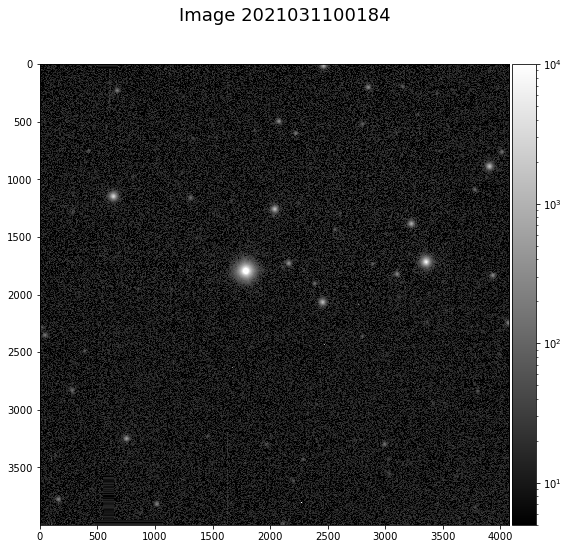

In [4]:
# Look at the data with matplotlib
from matplotlib.colors import LogNorm
# Now let's look at ithem
def colorbar(mappable):
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    last_axes = plt.gca()
    ax = mappable.axes
    fig = ax.figure
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(mappable, cax=cax)
    plt.sca(last_axes)
    return cbar

plt.figure(figsize=(8,8))
plt.suptitle(f"Image {expId}",fontsize=18)
arr = exp.image.array
arr = np.clip(arr, 1, 150000) # This image has some negative values, and this removes them
img = plt.imshow(arr,  norm=LogNorm(vmin=5, vmax=10000), interpolation='Nearest', cmap='gray')
colorbar(img)
plt.tight_layout(h_pad=1)
#plt.savefig(REPO_DIR+"/plots/NGC4755_17Feb21.pdf")